# Assignment 11

## Data mirroring
We begin by doubling the size of the dataset by mirroring both the cut and uncut files around the y-axis.

In [28]:
import pandas as pd
import os
import glob


folders = [
    "../../data/kinect_good_preprocessed_not_cut_A11_mediapipe",
    "../../data/kinect_good_preprocessed_A9_mediapipe"
]

pairs = [
    ('left_shoulder', 'right_shoulder'),
    ('left_elbow', 'right_elbow'),
    ('left_wrist', 'right_wrist'),
    ('left_hip', 'right_hip'),
    ('left_knee', 'right_knee'),
    ('left_ankle', 'right_ankle')
]

for target_folder in folders:
    all_files = glob.glob(os.path.join(target_folder, "*.csv"))
    print(f"Processing folder: {target_folder} ({len(all_files)} files found)")
    
    count = 0
    for f in all_files:
        if "_mirrored" in f: 
            continue
        
        df = pd.read_csv(f)
        mirrored_df = df.copy()
        
        x_cols = [c for c in df.columns if "_3d_x" in c]
        mirrored_df[x_cols] = 1.0 - df[x_cols]
        
        for left, right in pairs:
            for axis in ['x', 'y', 'z']:
                l_col = f"{left}_3d_{axis}"
                r_col = f"{right}_3d_{axis}"
                
                if l_col in df.columns and r_col in df.columns:
                    mirrored_df[l_col] = df[r_col]
                    mirrored_df[r_col] = df[l_col]
                    
                    if axis == 'x':
                        mirrored_df[l_col] = 1.0 - mirrored_df[l_col]
                        mirrored_df[r_col] = 1.0 - mirrored_df[r_col]

        new_path = f.replace(".csv", "_mirrored.csv")
        mirrored_df.to_csv(new_path, index=False)
        count += 1

    print(f"Successfully created {count} mirrored files in {target_folder}.\n")

print("All folders processed.")

Processing folder: ../../data/kinect_good_preprocessed_not_cut_A11_mediapipe (360 files found)
Successfully created 180 mirrored files in ../../data/kinect_good_preprocessed_not_cut_A11_mediapipe.

Processing folder: ../../data/kinect_good_preprocessed_A9_mediapipe (358 files found)
Successfully created 179 mirrored files in ../../data/kinect_good_preprocessed_A9_mediapipe.

All folders processed.


## Data labelling - Creating data
Here we join the uncut and cut files to create the actual data. This creates the files we use for training, validation aswell as testing.

In [29]:
import pandas as pd
import os
import glob
from tqdm import tqdm


cut_folder = "../../data/kinect_good_preprocessed_A9_mediapipe"
uncut_folder = "../../data/kinect_good_preprocessed_not_cut_A11_mediapipe"
output_folder = "../../data/labeled_files" 

os.makedirs(output_folder, exist_ok=True)

uncut_files = glob.glob(os.path.join(uncut_folder, "*.csv"))

print(f"Found {len(uncut_files)} uncut files. Starting labeling...")

for uncut_path in tqdm(uncut_files):
    filename = os.path.basename(uncut_path)
    cut_path = os.path.join(cut_folder, filename)
    
    if not os.path.exists(cut_path):
        print(f"Warning: No cut file found for {filename}. Skipping.")
        continue
        
    df_uncut = pd.read_csv(uncut_path)
    df_cut = pd.read_csv(cut_path)
    

    start_frame = df_cut['FrameNo'].min()
    end_frame = df_cut['FrameNo'].max()
    
    # Label 1 if the frame is within the range, otherwise 0
    df_uncut['activity_label'] = (
        (df_uncut['FrameNo'] >= start_frame) & 
        (df_uncut['FrameNo'] <= end_frame)
    ).astype(int)
    
    save_path = os.path.join(output_folder, filename)
    df_uncut.to_csv(save_path, index=False)

print(f"\nDone! Labeled files saved to: {output_folder}")

Found 360 uncut files. Starting labeling...


 34%|███▍      | 124/360 [00:01<00:01, 118.01it/s]

100%|█████████▉| 359/360 [00:03<00:00, 120.92it/s]

100%|██████████| 360/360 [00:03<00:00, 116.60it/s]


Done! Labeled files saved to: ../../data/labeled_files


## Training the model

## Configuration

In [30]:
#config = {
#    "epochs": 30,
#    "patience": 5,
#    "batch_size": 64,
#    "lr": 0.0005,
#    "hidden_size": 128,
#    "num_layers": 2,
#    "seq_length": 5,
#    "dropout": 0.2,
#    "input_size": 39,
#    "note": "Baseline"
#}

experiment_variants = [
    {
        "note": "GRU",
        "seed": 42,
        "seq_length": 5,
        "hidden_size": 128,
        "lr": 0.0005,
        "batch_size": 64,
        "epochs": 30,
        "patience": 5,
        "num_layers": 2,
        "dropout": 0.2,
        "input_size": 39,
        "use_scaling": False,
        "activation": "identity",
        "init": "default",
        "bidirectional": True,
        "rnn_type": "GRU",
    },
    {
        "note": "GRU",
        "seed": 42,
        "seq_length": 5,
        "hidden_size": 128,
        "lr": 0.0005,
        "batch_size": 64,
        "epochs": 30,
        "patience": 5,
        "num_layers": 2,
        "dropout": 0.2,
        "input_size": 39,
        "use_scaling": False,
        "activation": "identity",
        "init": "default",
        "bidirectional": False,
        "rnn_type": "GRU",
    },
        {
        "note": "GRU",
        "seed": 42,
        "seq_length": 5,
        "hidden_size": 128,
        "lr": 0.0005,
        "batch_size": 64,
        "epochs": 30,
        "patience": 5,
        "num_layers": 2,
        "dropout": 0.2,
        "input_size": 39,
        "use_scaling": True,
        "activation": "identity",
        "init": "default",
        "bidirectional": True,
        "rnn_type": "GRU",
    },
    {
        "note": "GRU",
        "seed": 42,
        "seq_length": 5,
        "hidden_size": 128,
        "lr": 0.0005,
        "batch_size": 64,
        "epochs": 30,
        "patience": 5,
        "num_layers": 2,
        "dropout": 0.2,
        "input_size": 39,
        "use_scaling": True,
        "activation": "identity",
        "init": "default",
        "bidirectional": False,
        "rnn_type": "GRU",
    },
]

### Classes

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torch.nn.init as init

class ActivityGatekeeper(nn.Module):
    def __init__(self, config):
        super(ActivityGatekeeper, self).__init__()
        
        # 1. Determine if we are using Bidirectional
        self.bidirectional = config.get("bidirectional", False)
        multiplier = 2 if self.bidirectional else 1
        
        # 2. Select RNN Type (LSTM or GRU)
        rnn_type = config.get("rnn_type", "LSTM")
        
        if rnn_type == "GRU":
            self.rnn = nn.GRU(
                config["input_size"], 
                config["hidden_size"], 
                config["num_layers"], 
                batch_first=True, 
                dropout=config["dropout"] if config["num_layers"] > 1 else 0,
                bidirectional=self.bidirectional
            )
        else:
            self.rnn = nn.LSTM(
                config["input_size"], 
                config["hidden_size"], 
                config["num_layers"], 
                batch_first=True, 
                dropout=config["dropout"] if config["num_layers"] > 1 else 0,
                bidirectional=self.bidirectional
            )
        
        # 3. Activation variant for the hidden state
        if config.get("activation") == "relu":
            self.act = nn.ReLU()
        elif config.get("activation") == "tanh":
            self.act = nn.Tanh()
        else:
            self.act = nn.Identity()
            
        # 4. Final Output Layer
        self.fc = nn.Linear(config["hidden_size"] * multiplier, 1)
        
        # 5. Initialization variant
        if config.get("init") == "xavier":
            init.xavier_uniform_(self.fc.weight)
        elif config.get("init") == "kaiming":
            init.kaiming_normal_(self.fc.weight)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_step = out[:, -1, :]
        activated = self.act(last_step)
        return self.fc(activated)

class ActivityDataset(Dataset):
    def __init__(self, file_paths, config, scaler=None):
        self.X, self.y = [], []
        seq_length = config["seq_length"]
        for path in file_paths:
            df = pd.read_csv(path)
            feat_cols = [c for c in df.columns if any(s in c for s in ['_x','_y','_z']) and 'FrameNo' not in c]
            X_data, y_data = df[feat_cols].values.astype('float32'), df['activity_label'].values.astype('float32')
            if scaler is not None:
                X_data = scaler.transform(X_data)

            if len(df) < seq_length: continue
            for i in range(len(df) - seq_length + 1):
                self.X.append(X_data[i : i + seq_length])
                self.y.append(y_data[i + seq_length - 1])
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return torch.tensor(self.X[idx]), torch.tensor([self.y[idx]])

def get_with_mirrors(file_list):
    res = []
    for f in file_list:
        res.append(f)
        m = f.replace(".csv", "_mirrored.csv")
        if os.path.exists(m): res.append(m)
    return res

import random
import numpy as np
import torch

def set_seed(seed=42):
    # Python's built-in random module
    random.seed(seed)
    
    # Numpy
    np.random.seed(seed)
    
    # PyTorch (CPU and GPU)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    # CuDNN determinism (Crucial for LSTMs on GPU)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"✅ Random seed set to: {seed}")




### Resample to make the dataset more balanced

In [32]:
import numpy as np

data_path = "../../data/labeled_files/"
originals = sorted([f for f in glob.glob(os.path.join(data_path, "*.csv")) if "_mirrored" not in f])

all_labels = []
for f in originals:
    all_labels.extend(pd.read_csv(f)['activity_label'].values)

neg, pos = np.bincount(np.array(all_labels).astype(int))
pos_weight = torch.tensor([neg / pos], dtype=torch.float).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Imbalance ratio: {neg/pos:.2f}")

Imbalance ratio: 0.57


### Training and evaluation

Initialized MLflow to track repo "SamuelFredricBerg/4dt907"

Repository SamuelFredricBerg/4dt907 initialized!

Using device: cpu
✅ Random seed set to: 42

--- Fold 1 ---
Fold 1 Results -> Precision: 0.9243, Recall: 0.8932, F1: 0.9085
New Absolute Best Model found in Fold 1!

--- Fold 2 ---
Fold 2 Results -> Precision: 0.9682, Recall: 0.8466, F1: 0.9034

--- Fold 3 ---
Fold 3 Results -> Precision: 0.8954, Recall: 0.9296, F1: 0.9122
New Absolute Best Model found in Fold 3!

--- Fold 4 ---
Fold 4 Results -> Precision: 0.9371, Recall: 0.8657, F1: 0.9000

--- Fold 5 ---
Fold 5 Results -> Precision: 0.9896, Recall: 0.7491, F1: 0.8527

--- Fold 6 ---
Fold 6 Results -> Precision: 0.8399, Recall: 0.9319, F1: 0.8835

--- Fold 7 ---
Fold 7 Results -> Precision: 0.9158, Recall: 0.8268, F1: 0.8690

--- Fold 8 ---
Fold 8 Results -> Precision: 0.8121, Recall: 0.9607, F1: 0.8802

--- Fold 9 ---
Fold 9 Results -> Precision: 0.9601, Recall: 0.8129, F1: 0.8804

--- Fold 10 ---
Fold 10 Results -> Precision: 0.9215, Recall: 0.9046, F1: 0.9130
New Absolute Best Model found in Fold 10!

TRAINING COMPLETE
Best Model p

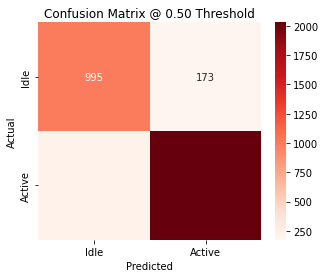

Comparing 0.8902839186053495 > 0.89242370883439
Mean performance did not beat @dev.
🏃 View run A11 - Experiments at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/50b54668578546779e0141c38e45e5b6
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
✅ Random seed set to: 42

--- Fold 1 ---
Fold 1 Results -> Precision: 0.9520, Recall: 0.8520, F1: 0.8992
New Absolute Best Model found in Fold 1!

--- Fold 2 ---
Fold 2 Results -> Precision: 0.9149, Recall: 0.8791, F1: 0.8966

--- Fold 3 ---
Fold 3 Results -> Precision: 0.9442, Recall: 0.9011, F1: 0.9222
New Absolute Best Model found in Fold 3!

--- Fold 4 ---
Fold 4 Results -> Precision: 0.9486, Recall: 0.8055, F1: 0.8712

--- Fold 5 ---
Fold 5 Results -> Precision: 0.9491, Recall: 0.8444, F1: 0.8937

--- Fold 6 ---
Fold 6 Results -> Precision: 0.9279, Recall: 0.7457, F1: 0.8269

--- Fold 7 ---
Fold 7 Results -> Precision: 0.9361, Recall: 0.8057, F1: 0.8660

--- Fold 8 ---
Fold

<Figure size 432x288 with 0 Axes>

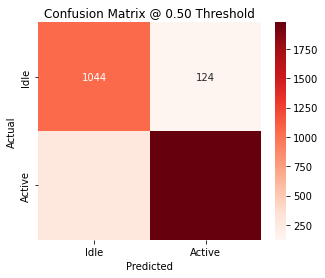

Comparing 0.8874810437441466 > 0.89242370883439
Mean performance did not beat @dev.
🏃 View run A11 - Experiments at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/40dbcfcf40d2402fa80dac3a6dc16a3b
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
✅ Random seed set to: 42

--- Fold 1 ---
Scaler fitted for Fold 1
Fold 1 Results -> Precision: 0.9243, Recall: 0.8932, F1: 0.9085
New Absolute Best Model found in Fold 1!

--- Fold 2 ---
Scaler fitted for Fold 2
Fold 2 Results -> Precision: 0.9682, Recall: 0.8466, F1: 0.9034

--- Fold 3 ---
Scaler fitted for Fold 3
Fold 3 Results -> Precision: 0.8954, Recall: 0.9296, F1: 0.9122
New Absolute Best Model found in Fold 3!

--- Fold 4 ---
Scaler fitted for Fold 4
Fold 4 Results -> Precision: 0.9371, Recall: 0.8657, F1: 0.9000

--- Fold 5 ---
Scaler fitted for Fold 5
Fold 5 Results -> Precision: 0.9896, Recall: 0.7491, F1: 0.8527

--- Fold 6 ---
Scaler fitted for Fold 6
Fold 6 Results

<Figure size 432x288 with 0 Axes>

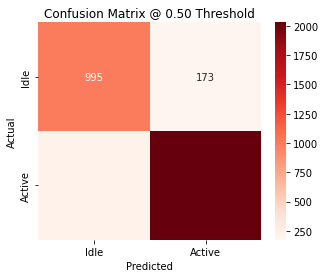

Comparing 0.8884153353645475 > 0.89242370883439
Mean performance did not beat @dev.
🏃 View run A11 - Experiments at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/ea9c648303204b12829b31b64b5d48e9
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
✅ Random seed set to: 42

--- Fold 1 ---
Scaler fitted for Fold 1
Fold 1 Results -> Precision: 0.9520, Recall: 0.8520, F1: 0.8992
New Absolute Best Model found in Fold 1!

--- Fold 2 ---
Scaler fitted for Fold 2
Fold 2 Results -> Precision: 0.9149, Recall: 0.8791, F1: 0.8966

--- Fold 3 ---
Scaler fitted for Fold 3
Fold 3 Results -> Precision: 0.9442, Recall: 0.9011, F1: 0.9222
New Absolute Best Model found in Fold 3!

--- Fold 4 ---
Scaler fitted for Fold 4
Fold 4 Results -> Precision: 0.9486, Recall: 0.8055, F1: 0.8712

--- Fold 5 ---
Scaler fitted for Fold 5
Fold 5 Results -> Precision: 0.9491, Recall: 0.8444, F1: 0.8937

--- Fold 6 ---
Scaler fitted for Fold 6
Fold 6 Results

<Figure size 432x288 with 0 Axes>

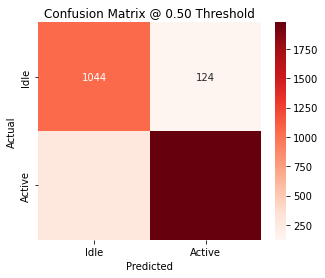

Comparing 0.8874810437441466 > 0.89242370883439
Mean performance did not beat @dev.
🏃 View run A11 - Experiments at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/e3e7765473904df89a1e22d02a5420fc
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0


<Figure size 432x288 with 0 Axes>

In [ ]:
import mlflow
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader
import torch.optim as optim
import sys
sys.path.append("../../scripts")

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import dagshub
import mlflow
import ml_utils as mlutils

import joblib


dagshub.init(repo_owner="SamuelFredricBerg", repo_name="4dt907", mlflow=True)
project_name = "Start_Stop_Predictor_Model"
utils = mlutils.mlutils(project_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_metrics = []
cv_fold_scores = []
cv_p_scores = []
cv_r_scores = []


for config in experiment_variants:
    set_seed(config["seed"])
    with mlflow.start_run(run_name="A11 - Experiments") as run:
        mlflow.log_params(config)

        best_overall_f1 = 0.0
        best_fold_info = ""

        for fold, (train_idx, test_idx) in enumerate(kf.split(originals)):
            print(f"\n--- Fold {fold+1} ---")

            # Splits files instead of segments
            train_orig = [originals[i] for i in train_idx]
            test_orig = [originals[i] for i in test_idx]

            scaler = None
            if config.get("use_scaling", False):
                scaler = MinMaxScaler()
                # Collect raw training data to fit
                train_samples = []
                for f in train_orig: # Use original files to get raw distribution
                    df = pd.read_csv(f)
                    feat_cols = [c for c in df.columns if any(s in c for s in ['_x','_y','_z']) and 'FrameNo' not in c]
                    train_samples.append(df[feat_cols].values)
                scaler.fit(np.vstack(train_samples))
                print(f"Scaler fitted for Fold {fold+1}")

            v_split = int(len(train_orig) * 0.9)
            # Adding mirrors only to training/val
            train_files = get_with_mirrors(train_orig[:v_split])
            val_files = get_with_mirrors(train_orig[v_split:])
            test_files = test_orig 

            # Creating loaders contating the data
            train_loader = DataLoader(ActivityDataset(train_files, config), batch_size=config["batch_size"], shuffle=True)
            val_loader = DataLoader(ActivityDataset(val_files, config), batch_size=config["batch_size"], shuffle=False)
            test_loader = DataLoader(ActivityDataset(test_files, config), batch_size=config["batch_size"], shuffle=False)

            model = ActivityGatekeeper(config).to(device)

            optimizer = optim.Adam(model.parameters(), lr=config["lr"]) 
            # This resamples the data
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

            # Initializing values
            best_v_loss, patience_count = float('inf'), 0
            fold_checkpoint_path = f"best_fold_{fold}.pth"


            # Each fold does max epochs 
            for epoch in range(config["epochs"]):
                model.train()
                for x, y in train_loader:
                    optimizer.zero_grad()
                    criterion(model(x.to(device)), y.to(device)).backward()
                    optimizer.step()

                model.eval()
                v_loss = 0
                with torch.no_grad():
                    for x, y in val_loader: 
                        v_loss += criterion(model(x.to(device)), y.to(device)).item()

                avg_v = v_loss / len(val_loader)
                if avg_v < best_v_loss:
                    best_v_loss = avg_v
                    patience_count = 0
                    torch.save(model.state_dict(), fold_checkpoint_path)
                else:
                    patience_count += 1
                    if patience_count >= config["patience"]: break


            model.load_state_dict(torch.load(fold_checkpoint_path)) 
            model.eval()
            t_true, t_preds = [], []
            with torch.no_grad():
                for inputs, labels in test_loader:
                    inputs = inputs.to(device)
                    outputs = torch.sigmoid(model(inputs))
                    t_preds.extend((outputs > 0.5).float().cpu().numpy())
                    t_true.extend(labels.numpy())

            # Evaluation 
            p = precision_score(t_true, t_preds, zero_division=0)
            r = recall_score(t_true, t_preds, zero_division=0)
            f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

            print(f"Fold {fold+1} Results -> Precision: {p:.4f}, Recall: {r:.4f}, F1: {f1:.4f}")


            cv_fold_scores.append(f1)
            cv_p_scores.append(p)
            cv_r_scores.append(r)


            # Only saves best model
            if f1 > best_overall_f1:
                best_overall_f1 = f1
                torch.save(model.state_dict(), "gatekeeper_best.pth")
                joblib.dump(scaler, "scaler_best.joblib")
                if os.path.exists("scaler_best.joblib"):
                    mlflow.log_artifact("scaler_best.joblib")
                best_fold_info = f"Fold {fold+1} (P: {p:.4f}, R: {r:.4f}, F1: {f1:.4f})"
                print(f"New Absolute Best Model found in Fold {fold+1}!")

            if os.path.exists(fold_checkpoint_path):
                os.remove(fold_checkpoint_path)

            if os.path.exists("scaler_best.joblib"):
                os.remove("scaler_best.joblib")

        mean_f1 = np.mean(cv_fold_scores)
        mlflow.log_metric("Mean_F1", mean_f1)

        std_f1 = np.std(cv_fold_scores)
        mlflow.log_metric("Std_Dev_F1", std_f1)

        mean_p = np.mean(cv_p_scores)
        mlflow.log_metric("Mean_Precision", mean_p)

        mean_r = np.mean(cv_r_scores)
        mlflow.log_metric("Mean_Recall", mean_r)

        cv_results_df = pd.DataFrame({'f1': cv_fold_scores})
        cv_results_df.to_csv("cv_fold_scores.csv", index=False)
        mlflow.log_artifact("cv_fold_scores.csv")


        print("\n" + "="*30)
        print(f"TRAINING COMPLETE")
        print(f"Best Model preserved from: {best_fold_info}")
        print("Final model saved as: gatekeeper_best.pth")
        print("="*30)

        is_better, p_val = utils.is_challenger_statistically_better(
            cv_fold_scores, 
            metric="Mean_F1"
        )

        # SAFE LOGGING: Only log if files exist (they won't on the very first run)
        import os
        if os.path.exists("model_confidence_comparison.png"):
            mlflow.log_artifact("model_confidence_comparison.png")

        if os.path.exists("challenger_vs_prod_ttest.png"):
            mlflow.log_artifact("challenger_vs_prod_ttest.png")

        if is_better:
            print(f"Challenger is statistically superior (p={p_val:.4f})")
        else:
            print(f"Difference not significant or model is worse (p={p_val:.4f})")

        cm = confusion_matrix(t_true, t_preds)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Idle', 'Active'], yticklabels=['Idle', 'Active'])
        plt.title("Confusion Matrix @ 0.50 Threshold")
        plt.xlabel("Predicted"); plt.ylabel("Actual")
        plt.show()
        plt.savefig("conf_matrix.png")
        mlflow.log_artifact("conf_matrix.png")

        if utils.auto_check_challenger(run.info.run_id, metric_name="Mean_F1"):
            # Load the overall best model back into memory to log it
            model.load_state_dict(torch.load("gatekeeper_best.pth"))
            mlflow.pytorch.log_model(model, "model", registered_model_name=project_name)

            # Set dev alias
            versions = utils.client.get_latest_versions(project_name)
            latest_v = versions[0].version
            utils.client.set_registered_model_alias(project_name, "dev", latest_v)
            print("Robust Model Registered to @dev")
        else:
            print("Mean performance did not beat @dev.")

# Creating confusion matrix

# One file check for manual control

In [34]:
import torch
import pandas as pd
import numpy as np

def extract_exercise_bounds(file_path, model_path, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ActivityGatekeeper(config).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    df = pd.read_csv(file_path)
    feat_cols = [c for c in df.columns if any(s in c for s in ['_x','_y','_z']) and 'FrameNo' not in c]
    X_data = df[feat_cols].values.astype('float32')
    frame_numbers = df['FrameNo'].values
    
    seq_length = config["seq_length"]
    predictions = []

    with torch.no_grad():
        for i in range(len(df) - seq_length + 1):
            window = X_data[i : i + seq_length]
            window_tensor = torch.tensor(window).unsqueeze(0).to(device)
            
            output = model(window_tensor)
            prob = torch.sigmoid(output).item()
            predictions.append(1 if prob >= 0.5 else 0)

    full_preds = [0] * (seq_length - 1) + predictions
    
    start_frame = None
    stop_frame = None

    for i in range(1, len(full_preds)):
        # Start: 0 -> 1 transition
        if full_preds[i-1] == 0 and full_preds[i] == 1:
            if start_frame is None: start_frame = frame_numbers[i]
        
        # Stop: 1 -> 0 transition
        if full_preds[i-1] == 1 and full_preds[i] == 0:
            stop_frame = frame_numbers[i-1]


    return start_frame, stop_frame

test_csv = "../../data/kinect_good_preprocessed_not_cut_A11_mediapipe/A2_kinect.csv"
model_file = "gatekeeper_best.pth"

start, stop = extract_exercise_bounds(test_csv, model_file, config)

print(f"File: {test_csv}")
print(f"Detected Start Frame: {start}")
print(f"Detected Stop Frame: {stop}")
if start and stop:
    print(f"Total Exercise Duration: {stop - start} frames")
else:
    print("Warning: Model did not detect a clear start/stop transition.")

File: ../../data/kinect_good_preprocessed_not_cut_A11_mediapipe/A2_kinect.csv
Detected Start Frame: 71
Detected Stop Frame: 221
Total Exercise Duration: 150 frames
